# Ансамбль

## Импорты

In [20]:
import re
import warnings
import numpy as np
import pandas as pd

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
from scipy.optimize import minimize

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def calculateMetrics(yTrue: np.ndarray, yPred: np.ndarray, modelName: str = "Model") -> float:
    f1Macro = f1_score(yTrue, yPred, average='macro')
    f1Binary = f1_score(yTrue, yPred, pos_label=1)
    print(f"{modelName.upper()} -> F1-Macro: {f1Macro:.5f} | F1-Binary: {f1Binary:.5f}")
    return f1Macro

## Загрузка данных

In [21]:
trainDataFrame = pd.read_csv('data/train.csv')
testDataFrame = pd.read_csv('data/test.csv')

print(f"Train shape: {trainDataFrame.shape}")
print(f"Test shape: {testDataFrame.shape}")
print(f"\nClass distribution:")
print(trainDataFrame['label'].value_counts())
print(f"\nClass balance: {trainDataFrame['label'].value_counts(normalize=True)}")

Train shape: (10800, 4)
Test shape: (973, 3)

Class distribution:
label
0.0    8730
1.0    2070
Name: count, dtype: int64

Class balance: label
0.0    0.808333
1.0    0.191667
Name: proportion, dtype: float64


## Предобработка текста (как в оригинале 2.ipynb)

In [22]:
def cleanText(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def buildText(df: pd.DataFrame) -> pd.Series:
    df["title"].fillna("", inplace=True)
    df["body"].fillna("", inplace=True)
    return (df["title"] + " " + df["body"]).apply(cleanText)

XTrainText = buildText(trainDataFrame)
XTestText = buildText(testDataFrame)
yTarget = trainDataFrame["label"].astype(int)

print("Предобработка завершена.")

Предобработка завершена.


## Векторизация (word + char_wb)

In [23]:
print("Векторизация текста (word-level)...")
wordVectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

print("Векторизация текста (char-level, char_wb)...")
charVectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    min_df=2,
    sublinear_tf=True
)

XTrainWord = wordVectorizer.fit_transform(XTrainText)
XTestWord = wordVectorizer.transform(XTestText)

XTrainChar = charVectorizer.fit_transform(XTrainText)
XTestChar = charVectorizer.transform(XTestText)

print(f"Word TF-IDF shape: {XTrainWord.shape}")
print(f"Char TF-IDF shape: {XTrainChar.shape}")

Векторизация текста (word-level)...
Векторизация текста (char-level, char_wb)...
Word TF-IDF shape: (10800, 50000)
Char TF-IDF shape: (10800, 50000)


## Объединение признаков

In [24]:
XTrainFinal = hstack([XTrainWord, XTrainChar])
XTestFinal = hstack([XTestWord, XTestChar])

print(f"Итоговая размерность train: {XTrainFinal.shape}")
print(f"Итоговая размерность test: {XTestFinal.shape}")

Итоговая размерность train: (10800, 100000)
Итоговая размерность test: (973, 100000)


## Модели и OOF предсказания (Stratified K-Fold)

In [25]:
models = {
    "lr": LogisticRegression(
        max_iter=3000,
        C=4.0,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    # "nb": ComplementNB(alpha=0.3),
    "sgd": SGDClassifier(
        loss="log_loss",
        alpha=1e-5,
        penalty="l2",
        class_weight="balanced",
        random_state=42,
        max_iter=3000,
        tol=1e-3
    ),
    # "et": ExtraTreesClassifier(
    #     n_estimators=500,
    #     max_depth=20,
    #     min_samples_split=5,
    #     class_weight="balanced",
    #     random_state=42,
    #     n_jobs=-1
    # )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oofPreds = {}
testPreds = {}
scores = {}

for name, model in models.items():
    print(f"Training {name.upper()}...")

    oofProba = cross_val_predict(
        model,
        XTrainFinal,
        yTarget,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oofPreds[name] = oofProba
    oofPredBinary = (oofProba >= 0.5).astype(int)
    calculateMetrics(yTarget, oofPredBinary, name.upper() + " OOF")
    scores[name] = f1_score(yTarget, oofPredBinary)

    model.fit(XTrainFinal, yTarget)
    testPreds[name] = model.predict_proba(XTestFinal)[:, 1]

print("\nВсе модели обучены на OOF!")

Training LR...
LR OOF -> F1-Macro: 0.88955 | F1-Binary: 0.82233
Training SGD...
SGD OOF -> F1-Macro: 0.88673 | F1-Binary: 0.81725

Все модели обучены на OOF!


## Оптимизация весов ансамбля перебором (как в bestEnsemble)


Оптимизация весов через minimize (быстро, как в bestEnsemble)...

Оптимальные веса: {'lr': np.float64(0.5), 'sgd': np.float64(0.5)}
Лучший F1 на OOF (с оптимальным порогом 0.56): 0.82044


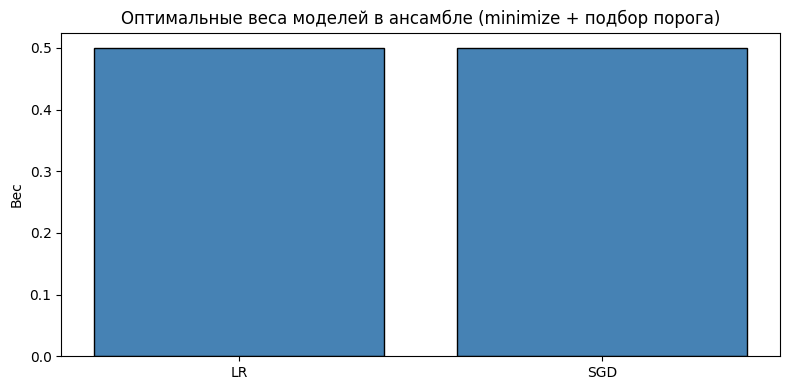

In [26]:
print("\nОптимизация весов через minimize (быстро, как в bestEnsemble)...")

oofProbasArray = np.column_stack([oofPreds[name] for name in models.keys()])
testProbasArray = np.column_stack([testPreds[name] for name in models.keys()])
modelNames = list(models.keys())
nModels = len(modelNames)

def ensembleLossFunction(weights: np.ndarray) -> float:
    """Loss = -F1 (минимизируем, т.е. максимизируем F1)"""
    weights = weights / np.sum(weights)
    oofEnsemble = oofProbasArray @ weights
    bestF1 = 0.0
    for thr in np.arange(0.2, 0.91, 0.01):
        f1 = f1_score(yTarget, (oofEnsemble >= thr).astype(int))
        if f1 > bestF1:
            bestF1 = f1
    return -bestF1

initialWeights = np.ones(nModels) / nModels
weightsConstraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
weightsBounds = [(0.0, 1.0) for _ in range(nModels)]

optimizationResult = minimize(
    ensembleLossFunction,
    initialWeights,
    method='SLSQP',
    bounds=weightsBounds,
    constraints=weightsConstraints,
    options={'maxiter': 200, 'ftol': 1e-8}
)

optimalWeights = optimizationResult.x / np.sum(optimizationResult.x)

oofEnsembleFinal = oofProbasArray @ optimalWeights
bestThrForWeights = 0.5
bestEnsembleF1 = 0.0
for thr in np.arange(0.2, 0.81, 0.01):
    f1 = f1_score(yTarget, (oofEnsembleFinal >= thr).astype(int))
    if f1 > bestEnsembleF1:
        bestEnsembleF1 = f1
        bestThrForWeights = thr

print(f"\nОптимальные веса: {dict(zip(modelNames, np.round(optimalWeights, 4)))}")
print(f"Лучший F1 на OOF (с оптимальным порогом {bestThrForWeights:.2f}): {bestEnsembleF1:.5f}")

plt.figure(figsize=(8, 4))
plt.bar(range(nModels), optimalWeights, color='steelblue', edgecolor='black')
plt.xticks(range(nModels), [m.upper() for m in modelNames])
plt.ylabel('Вес')
plt.title('Оптимальные веса моделей в ансамбле (minimize + подбор порога)')
plt.tight_layout()
plt.show()

## Взвешенный ансамбль с оптимальными весами

In [27]:
ensembleProba = testProbasArray @ optimalWeights

print(f"\nBest threshold: {bestThrForWeights:.2f}")
print(f"OOF Ensemble F1 (binary): {bestEnsembleF1:.5f}")

oofPredFinal = (oofEnsembleFinal >= bestThrForWeights).astype(int)
calculateMetrics(yTarget, oofPredFinal, "OOF Ensemble")


Best threshold: 0.56
OOF Ensemble F1 (binary): 0.82044
OOF ENSEMBLE -> F1-Macro: 0.88912 | F1-Binary: 0.82044


0.8891212079478159

## Финальные предсказания на тесте и submission

In [28]:
finalPred = (ensembleProba >= bestThrForWeights).astype(int)

submissionDataFrame = pd.DataFrame({
    "id": testDataFrame["id"],
    "label": finalPred
})

submissionDataFrame.to_csv('submission_ensemble.csv', index=False)

print("\n=== Финальная модель ===")
print(f"Predicted {finalPred.sum()} positive cases out of {len(finalPred)} total")
print(f"\nРаспределение предсказанных классов:")
print(submissionDataFrame['label'].value_counts().sort_index())

print("\nПервые 10 предсказаний:")
print(submissionDataFrame.head(10))

print("\nСохранен файл: submission_ensemble.csv")


=== Финальная модель ===
Predicted 220 positive cases out of 973 total

Распределение предсказанных классов:
label
0    753
1    220
Name: count, dtype: int64

Первые 10 предсказаний:
   id  label
0   0      0
1   1      0
2   2      0
3   3      0
4   4      1
5   5      0
6   6      0
7   7      1
8   8      0
9   9      1

Сохранен файл: submission_ensemble.csv


## Итоговая оценка (на train)

In [29]:
print("\n=== Итоговые метрики на train ===")
calculateMetrics(yTarget, oofPredFinal, "Final Ensemble ")

print("\nClassification Report (OOF):")
print(classification_report(yTarget, oofPredFinal))

print("\nConfusion Matrix (OOF):")
print(confusion_matrix(yTarget, oofPredFinal))


=== Итоговые метрики на train ===
FINAL ENSEMBLE  -> F1-Macro: 0.88912 | F1-Binary: 0.82044

Classification Report (OOF):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      8730
           1       0.83      0.81      0.82      2070

    accuracy                           0.93     10800
   macro avg       0.89      0.89      0.89     10800
weighted avg       0.93      0.93      0.93     10800


Confusion Matrix (OOF):
[[8376  354]
 [ 384 1686]]
